# 用python告诉你为什么十二平均律有12个音

作为一名学音乐的艺术生，为什么平均律现行的是12个音而不是其他的选择，我们需要一个合理的解释。后现代解构主义喜欢把所有的锅都甩给“文化上下文”跟“历史的偶然性”，这是很不负责任的表现。

![](res/人文三连.svg)

本文的目的是通过简单的数学和python可视化工具来解释为什么平均律是12个音。以下是正文。

任何数学工具都要从人的需求开始，因此我们先从音乐的角度说人话。

从听感的角度，我们将音程分为两种：

- 和谐音程
- 不和谐音程

这里我们有了第一个需求：**和谐音程比不和谐音程有更高的优先级，也就是说我们优先考虑让和谐音程尽量和谐**。

因为我们的生理构造以及各种神秘的原因，和谐音程对应的都是这种形式的比例：

$$\frac{k+1}{k}, k = \{1,2,3,...\}$$

例如：

- $\frac21$ = 纯八度
- $\frac32$ = 纯五度
- $\frac43$ = 纯四度
- $\frac54$ = 大三度
- $\frac65$ = 小三度

In [1]:
from enum import Enum
class INTERVALS(Enum):
    P8 = 2/1
    P5 = 3/2
    P4 = 4/3
    M3 = 5/4
    m3 = 6/5

因此我们想要一个n-平均律，使得这一平均律最好地照顾到这些和谐音程。

本文的目的就是解释为什么当$n=12$的时候是最优解。

## 定义损失函数

怎么样算“照顾到这些和谐音程”？我们需要找到一种衡量n-平均律跟这些和谐音程之间的“距离”，来判定n-平均律的优劣。

当我们定义了一个n-平均律，我们将八度分为了n等份，同时也生成了n个音程：

- 第1个音程：$2^{\frac1n}$
- 第2个音程：$2^{\frac2n}$
- ...
- 第i个音程：$2^{\frac{i}{n}}$

我们想要的就是：**对于任何一个和谐音程，存在一个n平均律中的音程，使得这两个音程之间的距离尽量小**。

例如，我们熟悉的12平均律（$n=12$），对于纯五度，我们可以找到12平均律中的第7个音程：

$$2^{\frac{7}{12}} = 1.4983070768766815$$

而这跟理想中的纯五度

$$\frac32 = 1.5$$

非常接近。

In [2]:
import numpy as np
np.abs(2**(7/12) - 1.5)

0.0016929231233184794

因此定义损失函数非常简单：遍历上文枚举出的和谐音程，对于任何一个和谐音程，找出在n-平均律中离这一和谐音程“距离”最近的一个音程然后计算“距离”。

既然上文提到了“距离”，我们可以很直观地直接用欧氏距离（毕竟从几何到统计学的MSE都在用这个）：

$$d(\vec x,\vec y) = \sqrt{(x_1 - y_1)^2 + ... + (x_k - y_k)^2}$$

也就是说

$$\text{损失函数}(\text{n-平均律}) = \sqrt{(\text{纯八度跟最接近的音程的距离})^2 + (\text{纯五度跟最接近的音程的距离})^2 + ...}$$

In [3]:
def loss(n):
    loss = 0
    for interval in INTERVALS:
        x = 2**(np.arange(0,n + 1) / n) - interval.value
        x = np.abs(x)
        x = np.min(x)
        x = np.square(x)
        loss = loss + x
    return np.sqrt(loss)

我们现在来看一下效果。

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

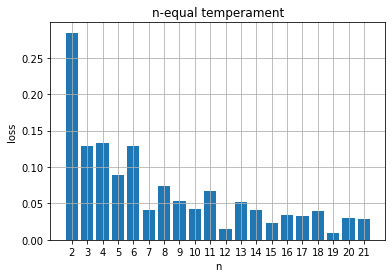

In [5]:
x = np.arange(2,25)
y = np.array(list(map(loss,x)))
data = pd.DataFrame({'n':x,'loss':y})

fig, ax = plt.subplots()
ax.set_xticks(data['n'].head(20))
ax.bar(data['n'].head(20),data['loss'].head(20))
ax.set(xlabel='n', ylabel='loss',
       title='n-equal temperament')
ax.grid()
plt.show()

## 进阶：两个可以考虑的问题

从上面已经可以看出来12对应着一个极小值，这也解释了为什么我们会选择12。

然而美中不足的是：19一样也很小，也就是说，19这一竞争者的存在让我们看不到12独特的光辉。

接下来我们可以用一个邪恶的招数：**通过修改“比赛规则”让12成为内定的冠军**。

### 不同的音程并非生而平等

我们可以提出第二个（伪）需求：**不同的和谐音程重要程度也不一样**。例如，或许我们觉得顾及纯五度比顾及小三度更加重要，也就是说我们更需要P5精准而不是m3。

从数学的角度来说，我们需要的是加入权重$\alpha_1,...,\alpha_k$。

$$\text{损失函数}(\text{n-平均律}) = \sqrt{\alpha_1(\text{纯八度跟最接近的音程的距离})^2 + \alpha_2(\text{纯五度跟最接近的音程的距离})^2 + ...}$$

权重该如何取值？一个很heuristic也是最为自然的办法就是直接用音程自身的值，因为我们发现**和谐音程的大小跟重要性呈正比**。

例如纯五度比小三度重要，恰好纯五度对应的$\frac32$比小三度对应的$\frac65$要大。

因此公式就成了

$$\text{损失函数}(\text{n-平均律}) = \sqrt{\frac21(\text{纯八度跟最接近的音程的距离})^2 + \frac32(\text{纯五度跟最接近的音程的距离})^2 + ...}$$

In [6]:
def loss(n):
    loss = 0
    for interval in INTERVALS:
        x = 2**(np.arange(0,n + 1) / n) - interval.value
        x = np.abs(x)
        x = np.min(x)
        x = interval.value * np.square(x)
        loss = loss + x
    return np.sqrt(loss)

### n的取值

另外一个直觉则是，n-平均律，n越大越不现实，毕竟作曲家和听众都会懵逼：比如如果一个八度有100万个音，那么我们大家都会集体懵逼。因此从regularization的角度来讲，我们可以加入对n的penalty：我们想要的是**小的损失函数，但是n也最好不要大**。

In [7]:
data.sort_values(by='loss') # 从这里可以看出来，另一个要考虑的feasibility问题就是n的大小：n越大越不现实，因此也可以加上一个penalty

,n,loss
17,19,0.009908
20,22,0.012017
22,24,0.014834
10,12,0.014834
13,15,0.023361
19,21,0.028531
18,20,0.030169
21,23,0.031397
15,17,0.033355
14,16,0.034023


所以一个最简单的方式就是把这个对n的regularization penalty放到损失函数中，**n越大损失越大**。

一个最简单且自然的选择就是选择n本身当做系数相乘

$$\text{损失函数}(\text{n-平均律}) = n \sqrt{\frac21(\text{纯八度跟最接近的音程的距离})^2 + \frac32(\text{纯五度跟最接近的音程的距离})^2 + ...}$$

In [8]:
def loss(n):
    loss = 0
    for interval in INTERVALS:
        x = 2**(np.arange(0,n + 1) / n) - interval.value
        x = np.abs(x)
        x = np.min(x)
        x = interval.value * np.square(x)
        loss = loss + x
    return n * np.sqrt(loss)

看一下效果：

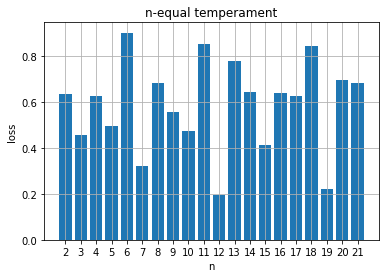

In [9]:
x = np.arange(2,25)
y = np.array(list(map(loss,x)))
data = pd.DataFrame({'n':x,'loss':y})

fig, ax = plt.subplots()
ax.set_xticks(data['n'].head(20))
ax.bar(data['n'].head(20),data['loss'].head(20))
ax.set(xlabel='n', ylabel='loss',
       title='n-equal temperament')
ax.grid()
plt.show()

如上，12这个数字成了唯一的最优解。

草稿

## 进阶：量化trade-off

平均律本质上就是trade-off：牺牲纯五纯四的纯度换取transposition-invariance。

我们接下来要找的就是一个最小的irreducible量：也就是说任何temperament都最少会损失“这么多”的“这个量”。